# Gold Price Dataset — Exploratory Data Analysis
---
**الهدف:** فهم الداتا قبل بناء الموديل  
**الخطوات:**
1. تحميل الداتا وفهم شكلها
2. Missing Values
3. إحصاءات وصفية
4. توزيع سعر الذهب
5. الـ Correlation مع كل الـ features
6. رسم الـ features الأهم مع الوقت
7. Seasonality
8. Outliers

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Data

In [2]:
df = pd.read_csv('gold_dataset.csv', index_col=0, parse_dates=True)

print(f'Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Total days : {(df.index[-1] - df.index[0]).days:,}')
print()
print('Columns:')
for col in df.columns:
    print(f'  {col}')

Shape      : 6,419 rows x 69 columns
Date range : 2000-08-30 → 2026-03-31
Total days : 9,344

Columns:
  Gold_Price
  Silver
  Oil_WTI
  Platinum
  Copper
  SP500
  Nasdaq
  Dow_Jones
  MSCI_World
  DXY
  EUR_USD
  JPY_USD
  GBP_USD
  CNY_USD
  US_10Y_Yield
  US_2Y_Yield
  TIP_ETF
  VIX
  Gold_ETF_GLD
  CPI
  Fed_Rate
  Real_Rate_10Y
  PPI
  M2_Money
  Treasury_Spread
  Unemployment
  GDP_Growth
  Industrial_Prod
  Consumer_Conf
  MA7
  EMA7
  MA14
  EMA14
  MA21
  EMA21
  MA50
  EMA50
  MA200
  EMA200
  Return_1d
  Return_3d
  Return_7d
  Return_14d
  Return_30d
  Lag_1d
  Lag_3d
  Lag_7d
  Lag_14d
  Lag_21d
  RSI_14
  MACD
  MACD_Signal
  MACD_Hist
  BB_Upper
  BB_Lower
  BB_Width
  BB_Pos
  Volatility_7d
  Volatility_30d
  Momentum_14d
  Gold_Silver_Ratio
  Gold_Oil_Ratio
  DayOfWeek
  Month
  Quarter
  Year
  Target_NextDay
  Target_Next7d
  Target_Direction


In [ ]:
df.head()

,Gold_Price,Silver,Oil_WTI,Platinum,Copper,SP500,Nasdaq,Dow_Jones,MSCI_World,DXY,...,Momentum_14d,Gold_Silver_Ratio,Gold_Oil_Ratio,DayOfWeek,Month,Quarter,Year,Target_NextDay,Target_Next7d,Target_Direction
Date,,,,,,,,,,,,,,,,,,,,,
2000-08-30,273.899994,4.930,33.400002,591.400024,0.8850,1502.589966,4103.810059,11103.009766,NaN,112.139999,...,NaN,55.557810,8.200598,2,8,3,2000,278.299988,273.299988,1
2000-08-31,278.299988,5.003,33.099998,586.700012,0.8850,1517.680054,4206.350098,11215.099609,NaN,112.599998,...,NaN,55.626624,8.407855,3,8,3,2000,277.000000,273.100006,0
2000-09-01,277.000000,5.004,33.380001,595.299988,0.8890,1520.770020,4234.330078,11238.780273,NaN,111.419998,...,NaN,55.355713,8.298382,4,9,3,2000,NaN,272.899994,0
2000-09-05,275.799988,4.998,33.799999,601.299988,0.9060,1507.079956,4143.180176,11260.610352,NaN,112.410004,...,NaN,55.182069,8.159763,1,9,3,2000,274.200012,272.399994,0
2000-09-06,274.200012,4.983,34.950001,611.099976,0.9015,1492.250000,4013.340088,11310.639648,NaN,114.120003,...,NaN,55.027097,7.845494,2,9,3,2000,274.000000,272.299988,0


In [4]:
df.tail()

,Gold_Price,Silver,Oil_WTI,Platinum,Copper,SP500,Nasdaq,Dow_Jones,MSCI_World,DXY,...,Momentum_14d,Gold_Silver_Ratio,Gold_Oil_Ratio,DayOfWeek,Month,Quarter,Year,Target_NextDay,Target_Next7d,Target_Direction
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-25,4549.799805,72.361000,90.320000,1925.199951,5.5290,6591.899902,21929.820312,46429.488281,181.190002,99.599998,...,-515.500000,62.876409,50.374223,2,3,1,2026,4375.500000,NaN,0
2026-03-26,4375.500000,67.670998,94.480003,1838.300049,5.4465,6477.160156,21408.080078,45960.109375,178.039993,99.900002,...,-770.600098,64.658423,46.311387,3,3,1,2026,4492.000000,4656.799805,1
2026-03-27,4492.000000,69.544998,99.639999,1870.599976,5.4670,6368.850098,20948.359375,45166.640625,175.419998,100.150002,...,-599.500000,64.591274,45.082297,4,3,1,2026,4526.000000,4657.100098,1
2026-03-30,4526.000000,70.323997,102.879997,1885.599976,5.4760,6343.720215,20794.640625,45216.140625,174.940002,100.510002,...,-703.700195,64.359254,43.993003,0,3,1,2026,4647.600098,4749.500000,1
2026-03-31,4647.600098,74.690002,101.379997,1950.000000,5.5875,6528.520020,21590.630859,46341.511719,180.020004,99.959999,...,-519.799805,62.225197,45.843364,1,3,1,2026,4783.200195,4792.200195,1


## 2. Missing Values

In [5]:
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype'         : df.dtypes
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing Count'] > 0].to_string())
print(f'\nColumns with NO missing values: {(missing["Missing Count"] == 0).sum()}')

                   Missing Count  Missing %    Dtype
MA200                       6419     100.00  float64
MA50                        6130      95.50  float64
MA21                        3969      61.83  float64
BB_Upper                    3821      59.53  float64
BB_Width                    3821      59.53  float64
BB_Lower                    3821      59.53  float64
BB_Pos                      3821      59.53  float64
RSI_14                      2955      46.04  float64
MSCI_World                  2848      44.37  float64
MA14                        2773      43.20  float64
MA7                         1372      21.37  float64
Gold_ETF_GLD                1056      16.45  float64
EUR_USD                      840      13.09  float64
GBP_USD                      827      12.88  float64
TIP_ETF                      818      12.74  float64
Platinum                     687      10.70  float64
CNY_USD                      444       6.92  float64
Lag_21d                      261       4.07  f

## 3. Descriptive Statistics

In [7]:
# Key market columns only
market_cols = ['Gold_Price', 'Silver', 'Oil_WTI', 'DXY', 'VIX', 'SP500',
               'US_10Y_Yield', 'RSI_14', 'Volatility_30d']
market_cols = [c for c in market_cols if c in df.columns]

df[market_cols].describe().round(2)

,Gold_Price,Silver,Oil_WTI,DXY,VIX,SP500,US_10Y_Yield,RSI_14,Volatility_30d
count,6419.00,6418.00,6418.00,6416.00,6414.00,6414.00,6409.00,3464.00,6390.00
mean,1285.97,18.58,64.77,92.53,19.78,2336.39,3.24,52.50,0.01
std,806.47,11.57,24.53,11.13,8.42,1525.61,1.22,17.12,0.00
min,255.10,4.03,-37.63,71.33,9.14,676.53,0.50,3.03,0.00
25%,652.80,12.25,46.52,82.55,13.96,1207.03,2.22,40.26,0.01
50%,1252.10,17.04,63.81,93.08,17.61,1643.10,3.36,52.22,0.01
75%,1700.35,23.75,82.00,99.52,23.11,2972.85,4.25,64.42,0.01
max,5318.40,115.08,145.29,120.90,82.69,6978.60,5.89,95.78,0.03


In [8]:
# FRED macroeconomic columns
fred_cols = ['CPI', 'Fed_Rate', 'Real_Rate_10Y', 'M2_Money',
             'Unemployment', 'GDP_Growth', 'Consumer_Conf']
fred_cols = [c for c in fred_cols if c in df.columns]

df[fred_cols].describe().round(2)

,CPI,Fed_Rate,Real_Rate_10Y,M2_Money,Unemployment,GDP_Growth,Consumer_Conf
count,6419.00,6419.00,6419.00,6419.00,6419.00,6335.00,6419.00
mean,235.93,1.92,1.14,12065.83,5.68,2.24,81.09
std,41.29,1.95,0.78,5623.05,1.96,5.04,13.55
min,172.70,0.05,-0.35,4819.50,3.50,-28.00,50.00
25%,204.23,0.14,0.52,7134.30,4.20,1.10,70.80
50%,232.90,1.26,1.11,10646.10,5.00,2.90,82.60
75%,256.04,3.72,1.74,15296.00,6.30,3.40,92.60
max,326.03,6.52,3.05,22386.90,14.80,34.90,107.60


## 4. Gold Price Over Time

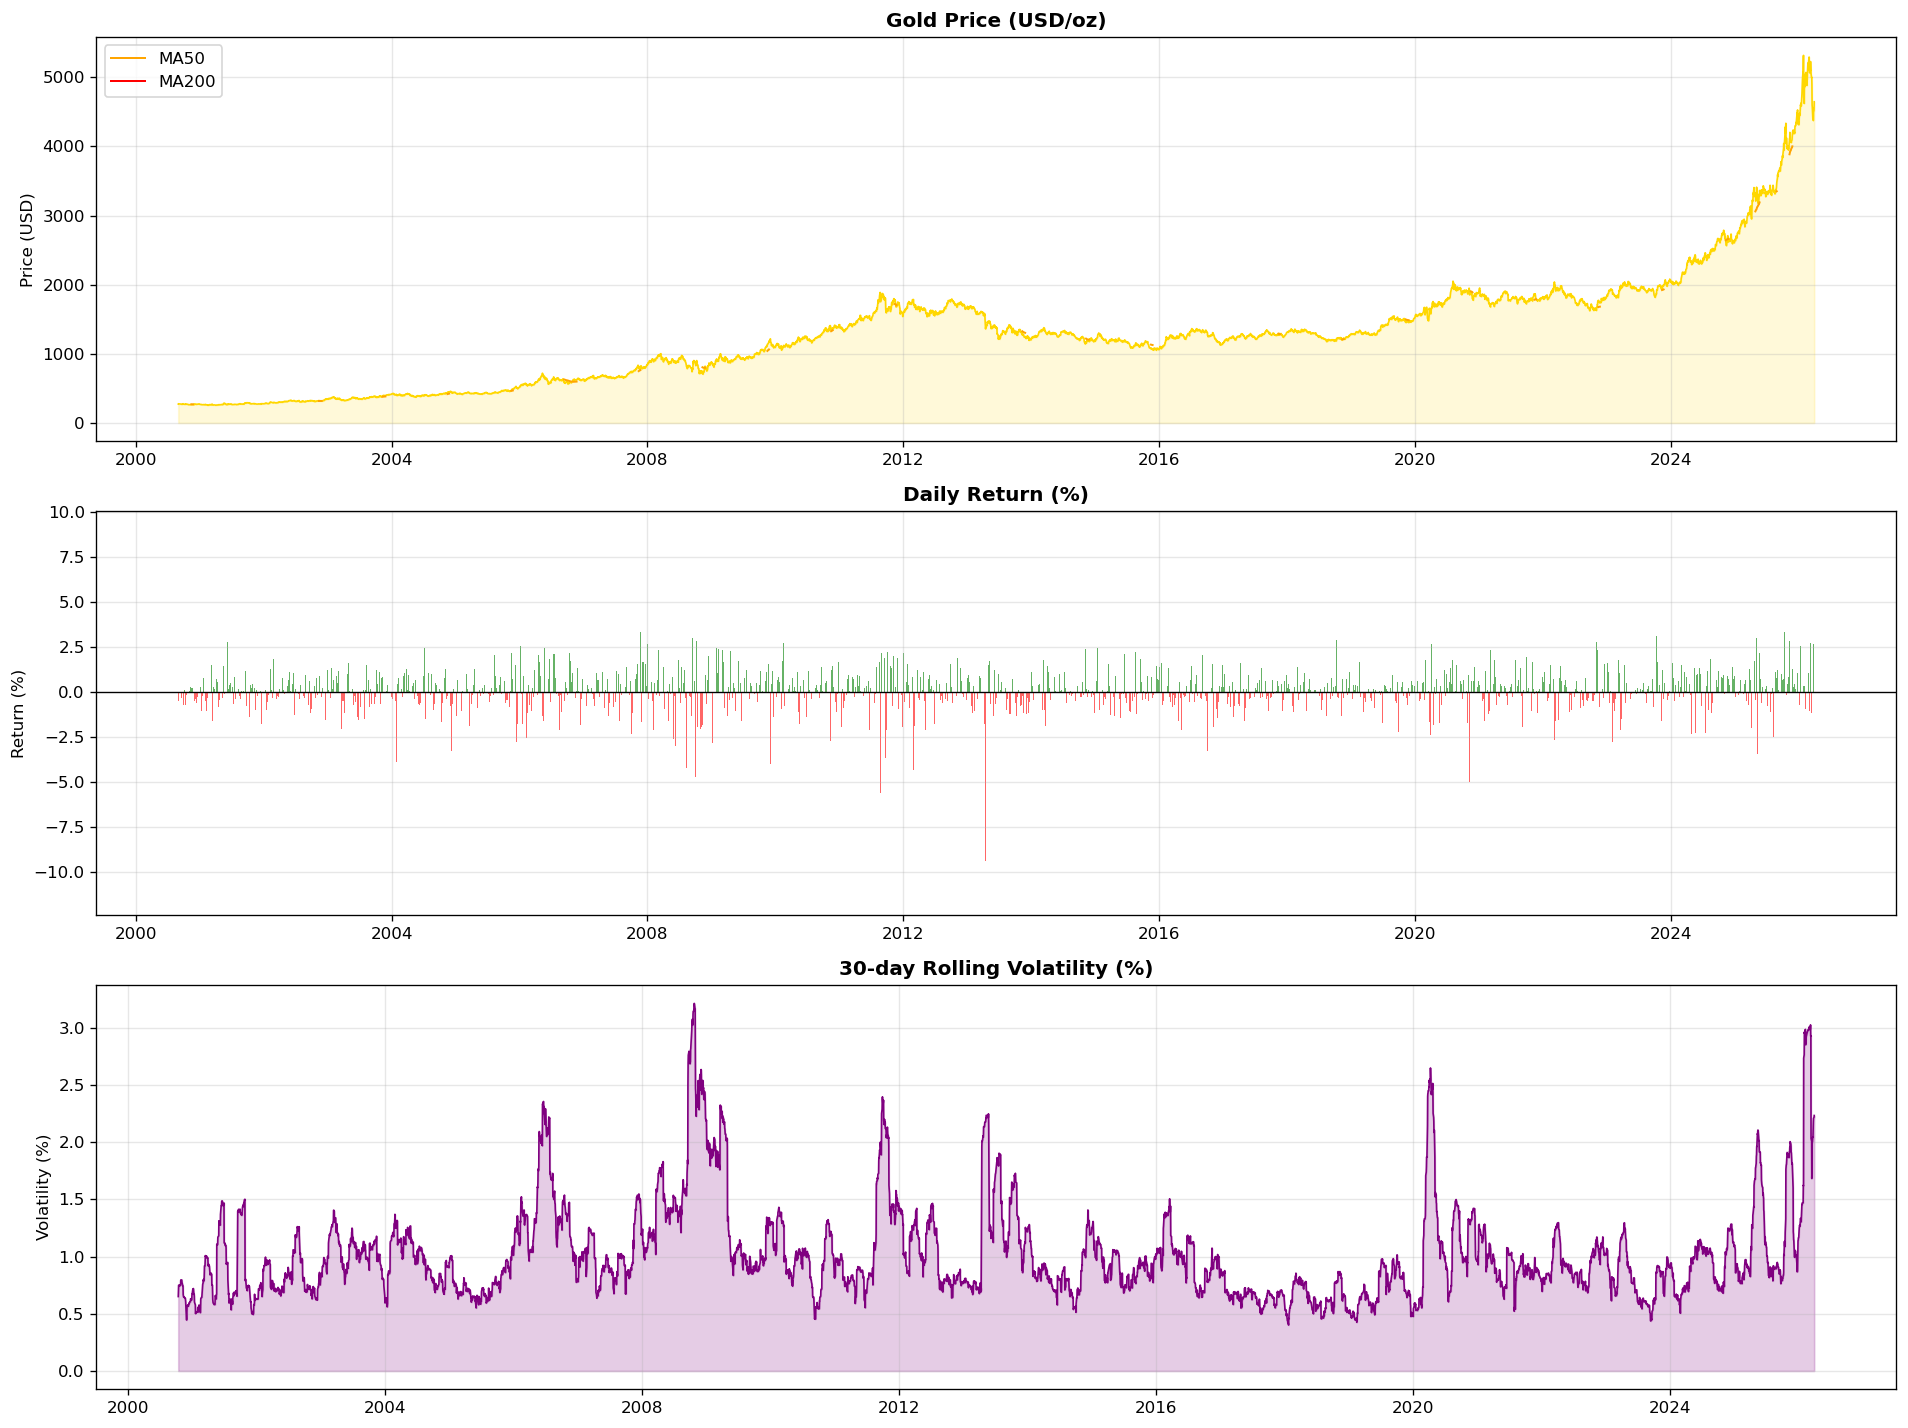

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# --- Price ---
axes[0].plot(df.index, df['Gold_Price'], color='gold', linewidth=1)
axes[0].fill_between(df.index, df['Gold_Price'], alpha=0.15, color='gold')
axes[0].set_title('Gold Price (USD/oz)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

# Add MA50 and MA200 if available
if 'MA50' in df.columns:
    axes[0].plot(df.index, df['MA50'],  label='MA50',  linewidth=1.2, color='orange')
if 'MA200' in df.columns:
    axes[0].plot(df.index, df['MA200'], label='MA200', linewidth=1.2, color='red')
axes[0].legend()

# --- Daily Return ---
ret = df['Return_1d'] * 100 if 'Return_1d' in df.columns else df['Gold_Price'].pct_change() * 100
colors = ['green' if r >= 0 else 'red' for r in ret]
axes[1].bar(df.index, ret, color=colors, alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Daily Return (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Return (%)')

# --- 30-day Volatility ---
if 'Volatility_30d' in df.columns:
    axes[2].plot(df.index, df['Volatility_30d'] * 100, color='purple', linewidth=1)
    axes[2].fill_between(df.index, df['Volatility_30d'] * 100, alpha=0.2, color='purple')
    axes[2].set_title('30-day Rolling Volatility (%)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Volatility (%)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 5. Distribution of Gold Price & Returns

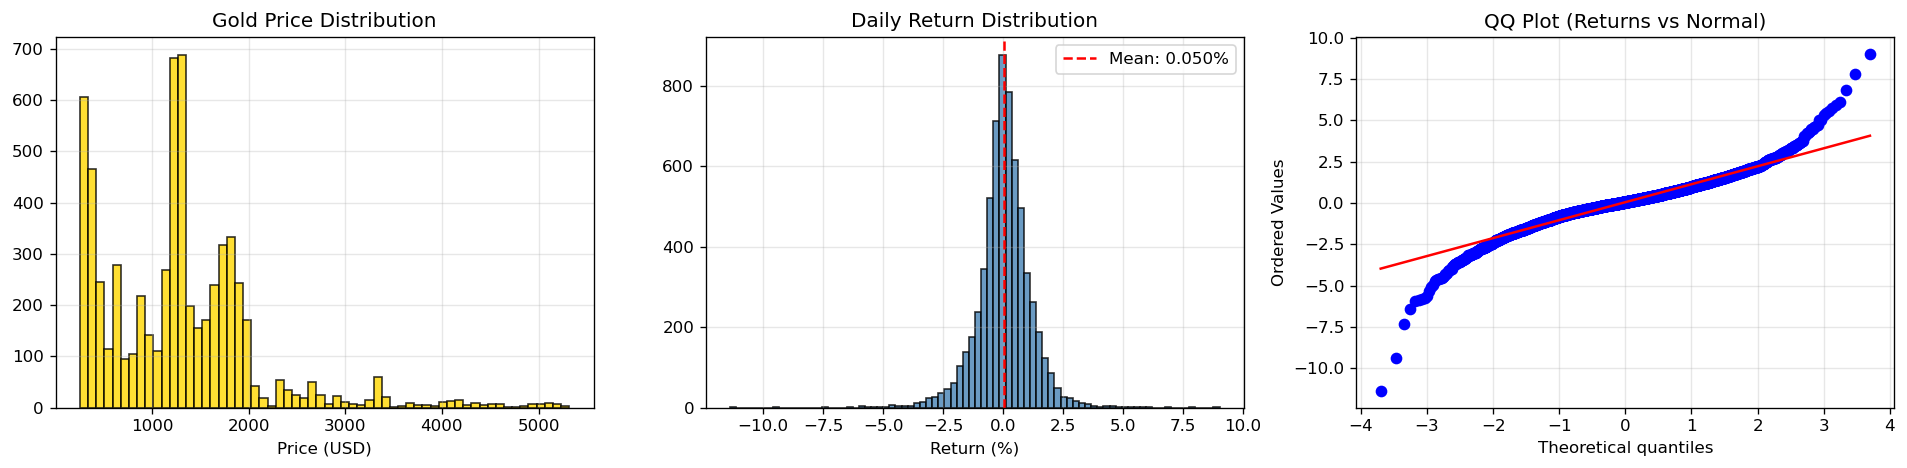

Skewness : -0.342  (0 = symmetric)
Kurtosis : 6.480  (0 = normal, >0 = fat tails)
Max gain : +9.03%
Max loss : -11.37%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price distribution
axes[0].hist(df['Gold_Price'].dropna(), bins=60, color='gold', edgecolor='black', alpha=0.8)
axes[0].set_title('Gold Price Distribution')
axes[0].set_xlabel('Price (USD)')

# Daily return distribution
ret = df['Return_1d'].dropna() * 100 if 'Return_1d' in df.columns else df['Gold_Price'].pct_change().dropna() * 100
axes[1].hist(ret, bins=80, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(ret.mean(), color='red', linestyle='--', label=f'Mean: {ret.mean():.3f}%')
axes[1].set_title('Daily Return Distribution')
axes[1].set_xlabel('Return (%)')
axes[1].legend()

# QQ plot — how close to normal distribution?
stats.probplot(ret, dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot (Returns vs Normal)')

plt.tight_layout()
plt.show()

# Stats
print(f'Skewness : {ret.skew():.3f}  (0 = symmetric)')
print(f'Kurtosis : {ret.kurtosis():.3f}  (0 = normal, >0 = fat tails)')
print(f'Max gain : +{ret.max():.2f}%')
print(f'Max loss : {ret.min():.2f}%')

## 6. Correlation with Gold Price

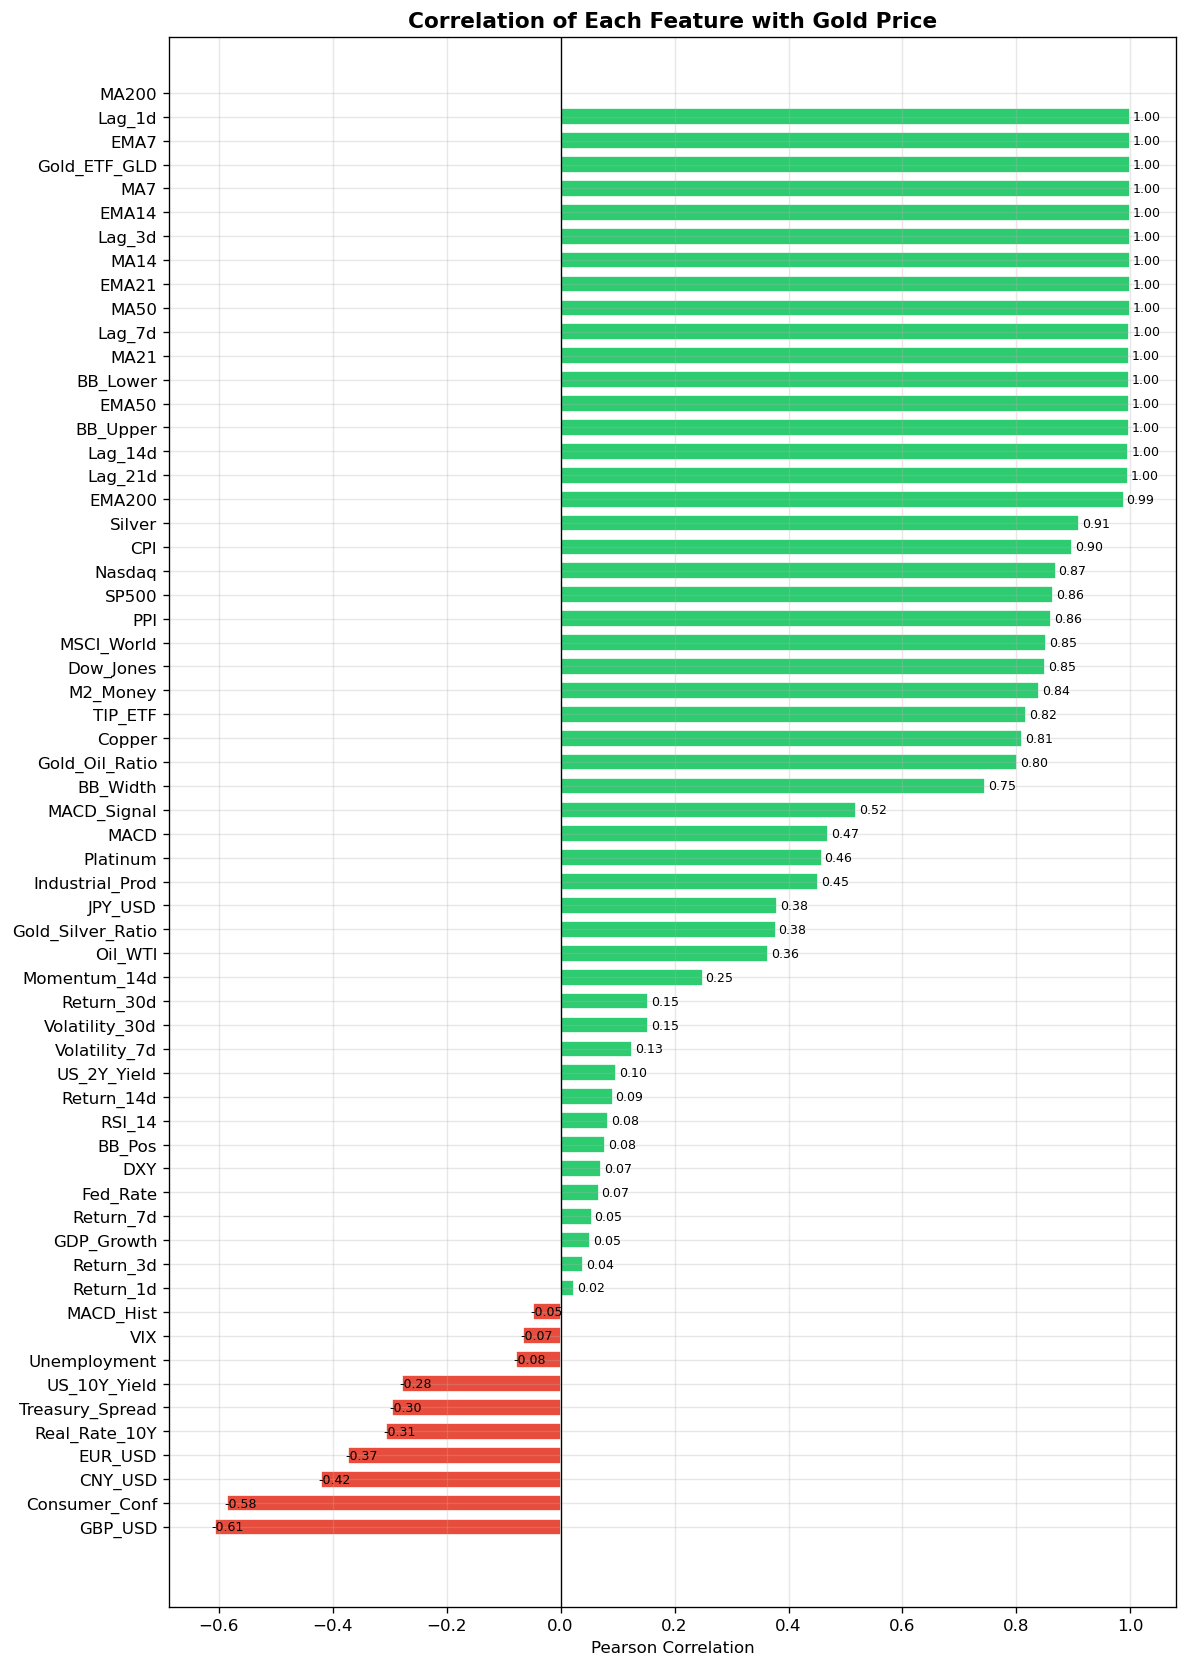


Top 10 POSITIVE correlations:
MA50            0.998428
EMA21           0.998835
MA14            0.998843
Lag_3d          0.999121
EMA14           0.999221
MA7             0.999447
Gold_ETF_GLD    0.999564
EMA7            0.999644
Lag_1d          0.999677
MA200                NaN

Top 10 NEGATIVE correlations:
GBP_USD           -0.607257
Consumer_Conf     -0.584639
CNY_USD           -0.420633
EUR_USD           -0.372510
Real_Rate_10Y     -0.305554
Treasury_Spread   -0.295831
US_10Y_Yield      -0.278407
Unemployment      -0.077907
VIX               -0.065909
MACD_Hist         -0.048706


In [11]:
# Compute correlation of every feature with Gold_Price
# Exclude target columns and calendar features
exclude = ['Target_NextDay', 'Target_Next7d', 'Target_Direction',
           'DayOfWeek', 'Month', 'Quarter', 'Year']
feature_cols = [c for c in df.columns if c not in exclude]

corr = df[feature_cols].corr()['Gold_Price'].drop('Gold_Price').sort_values()

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Each Feature with Gold Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')

# Annotate values
for i, (val, name) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + 0.005 * np.sign(val), i, f'{val:.2f}',
            va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

print('\nTop 10 POSITIVE correlations:')
print(corr.tail(10).to_string())
print('\nTop 10 NEGATIVE correlations:')
print(corr.head(10).to_string())

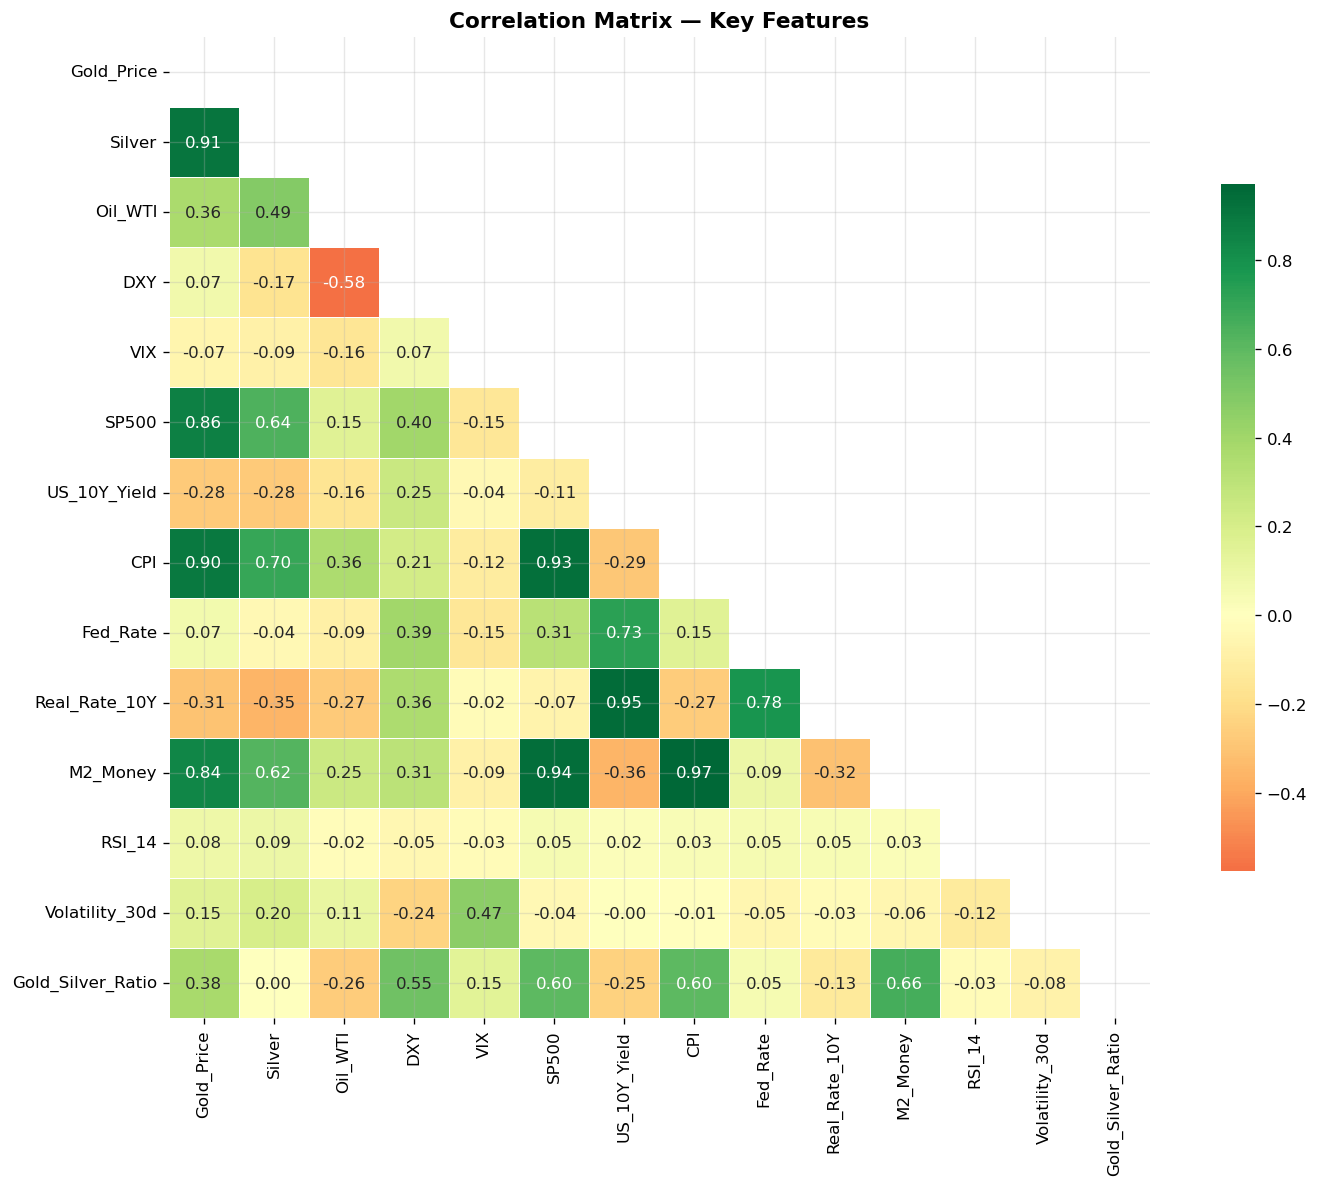

In [12]:
# Correlation heatmap — key features only
key_features = [
    'Gold_Price', 'Silver', 'Oil_WTI', 'DXY', 'VIX', 'SP500',
    'US_10Y_Yield', 'CPI', 'Fed_Rate', 'Real_Rate_10Y',
    'M2_Money', 'RSI_14', 'Volatility_30d', 'Gold_Silver_Ratio'
]
key_features = [c for c in key_features if c in df.columns]

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Correlation Matrix — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Key Features vs Gold Price Over Time

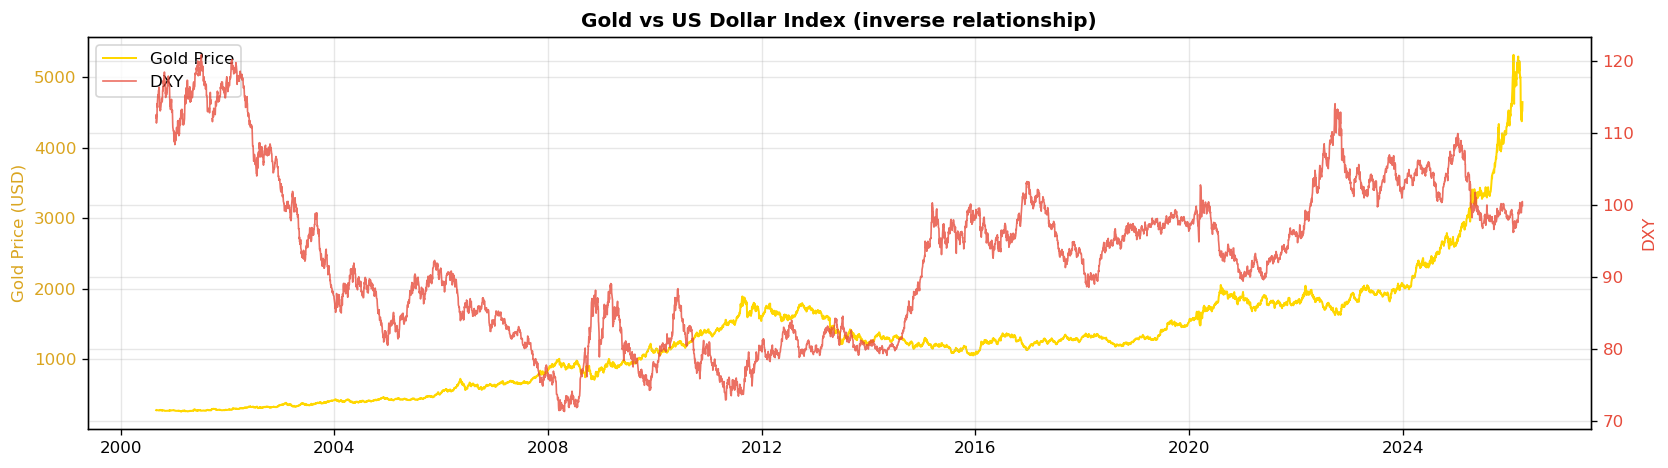

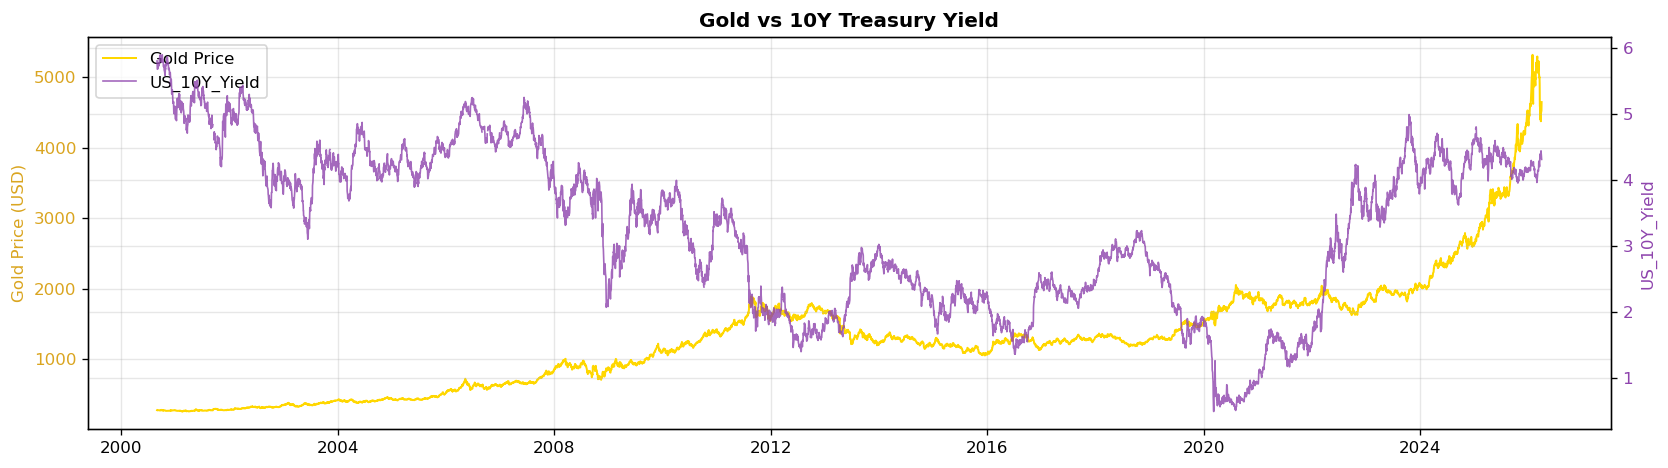

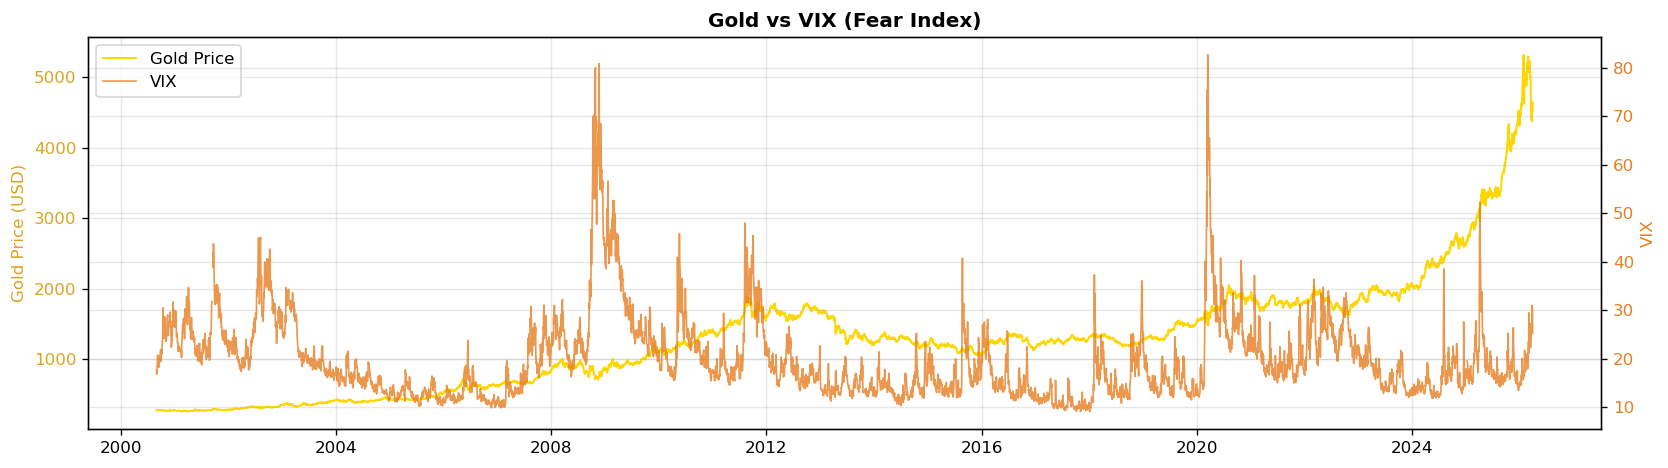

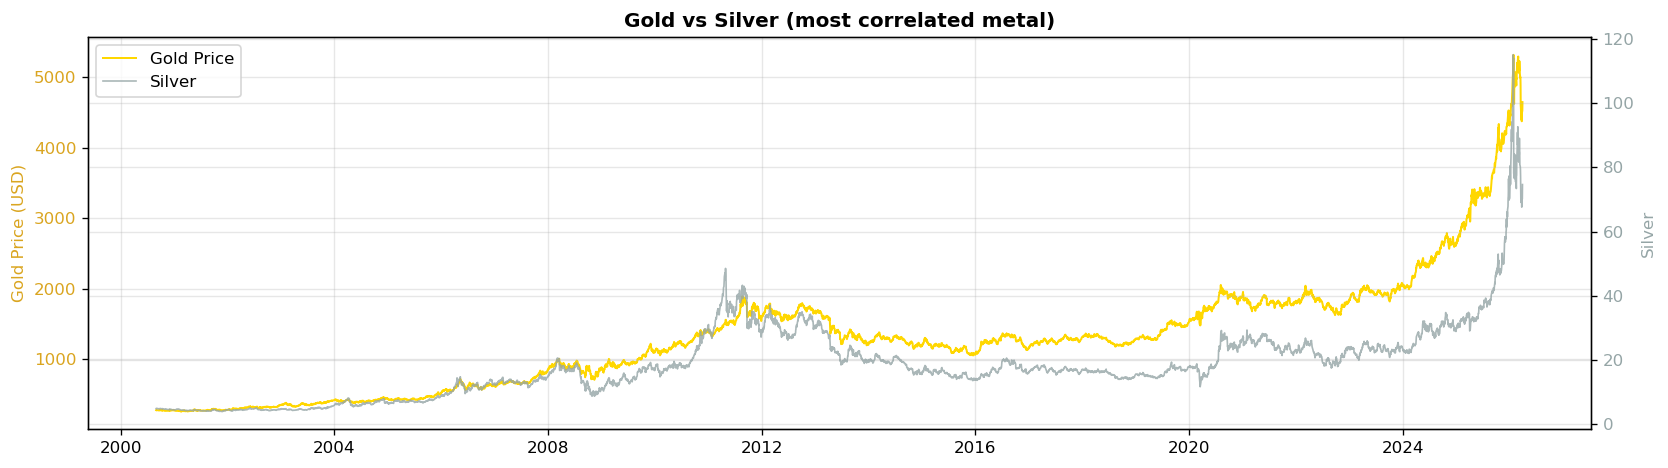

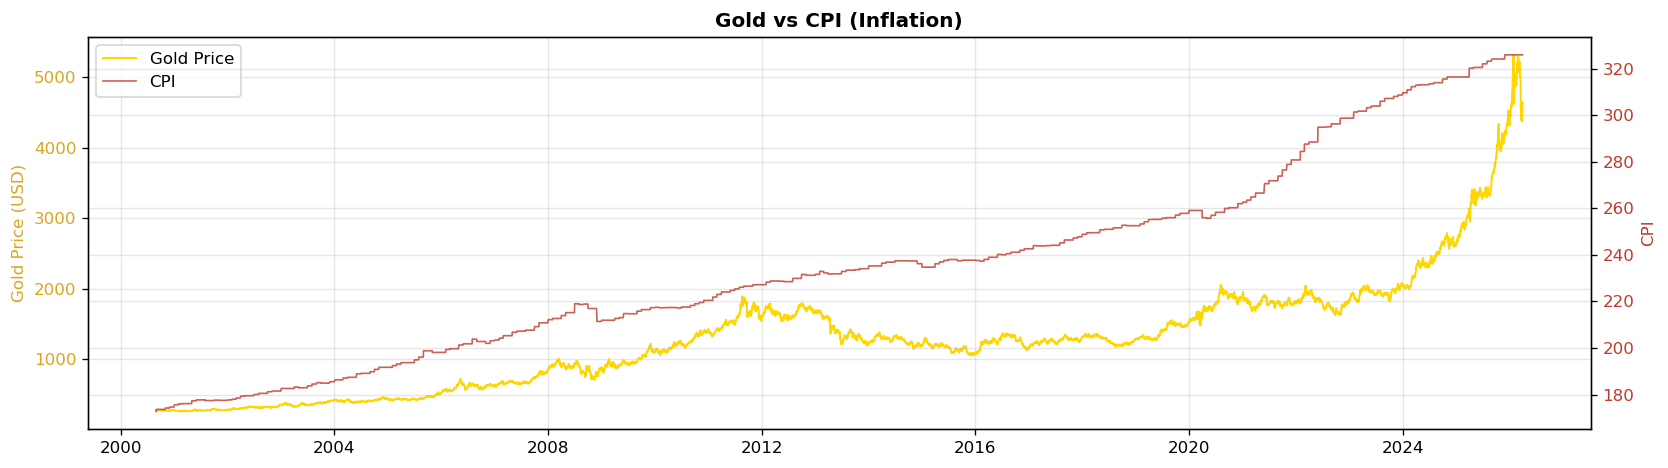

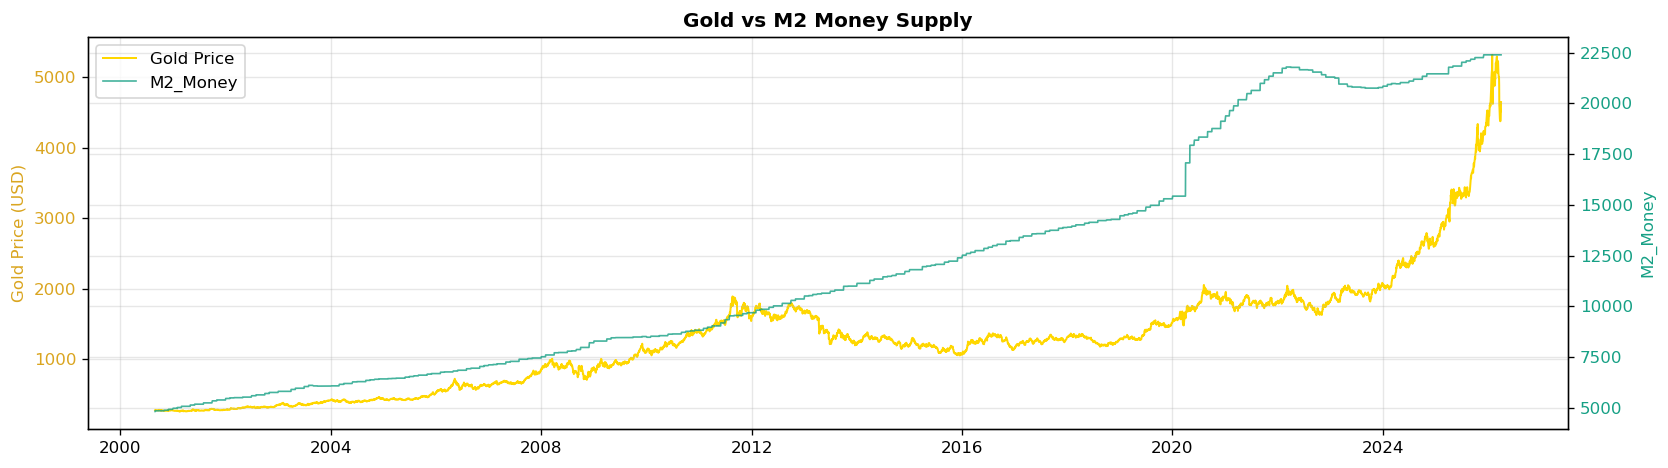

In [13]:
def dual_axis_plot(feature, title, color='steelblue'):
    """Plot Gold Price and one feature on dual y-axes."""
    if feature not in df.columns:
        print(f'Column {feature} not found')
        return
    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()

    ax1.plot(df.index, df['Gold_Price'], color='gold', linewidth=1.2, label='Gold Price')
    ax2.plot(df.index, df[feature], color=color, linewidth=1, alpha=0.8, label=feature)

    ax1.set_ylabel('Gold Price (USD)', color='goldenrod')
    ax2.set_ylabel(feature, color=color)
    ax1.tick_params(axis='y', labelcolor='goldenrod')
    ax2.tick_params(axis='y', labelcolor=color)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.set_title(title, fontsize=12, fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()


dual_axis_plot('DXY',          'Gold vs US Dollar Index (inverse relationship)',  color='#e74c3c')
dual_axis_plot('US_10Y_Yield', 'Gold vs 10Y Treasury Yield',                     color='#8e44ad')
dual_axis_plot('VIX',          'Gold vs VIX (Fear Index)',                        color='#e67e22')
dual_axis_plot('Silver',       'Gold vs Silver (most correlated metal)',           color='#95a5a6')
dual_axis_plot('CPI',          'Gold vs CPI (Inflation)',                         color='#c0392b')
dual_axis_plot('M2_Money',     'Gold vs M2 Money Supply',                        color='#16a085')

## 8. Technical Indicators

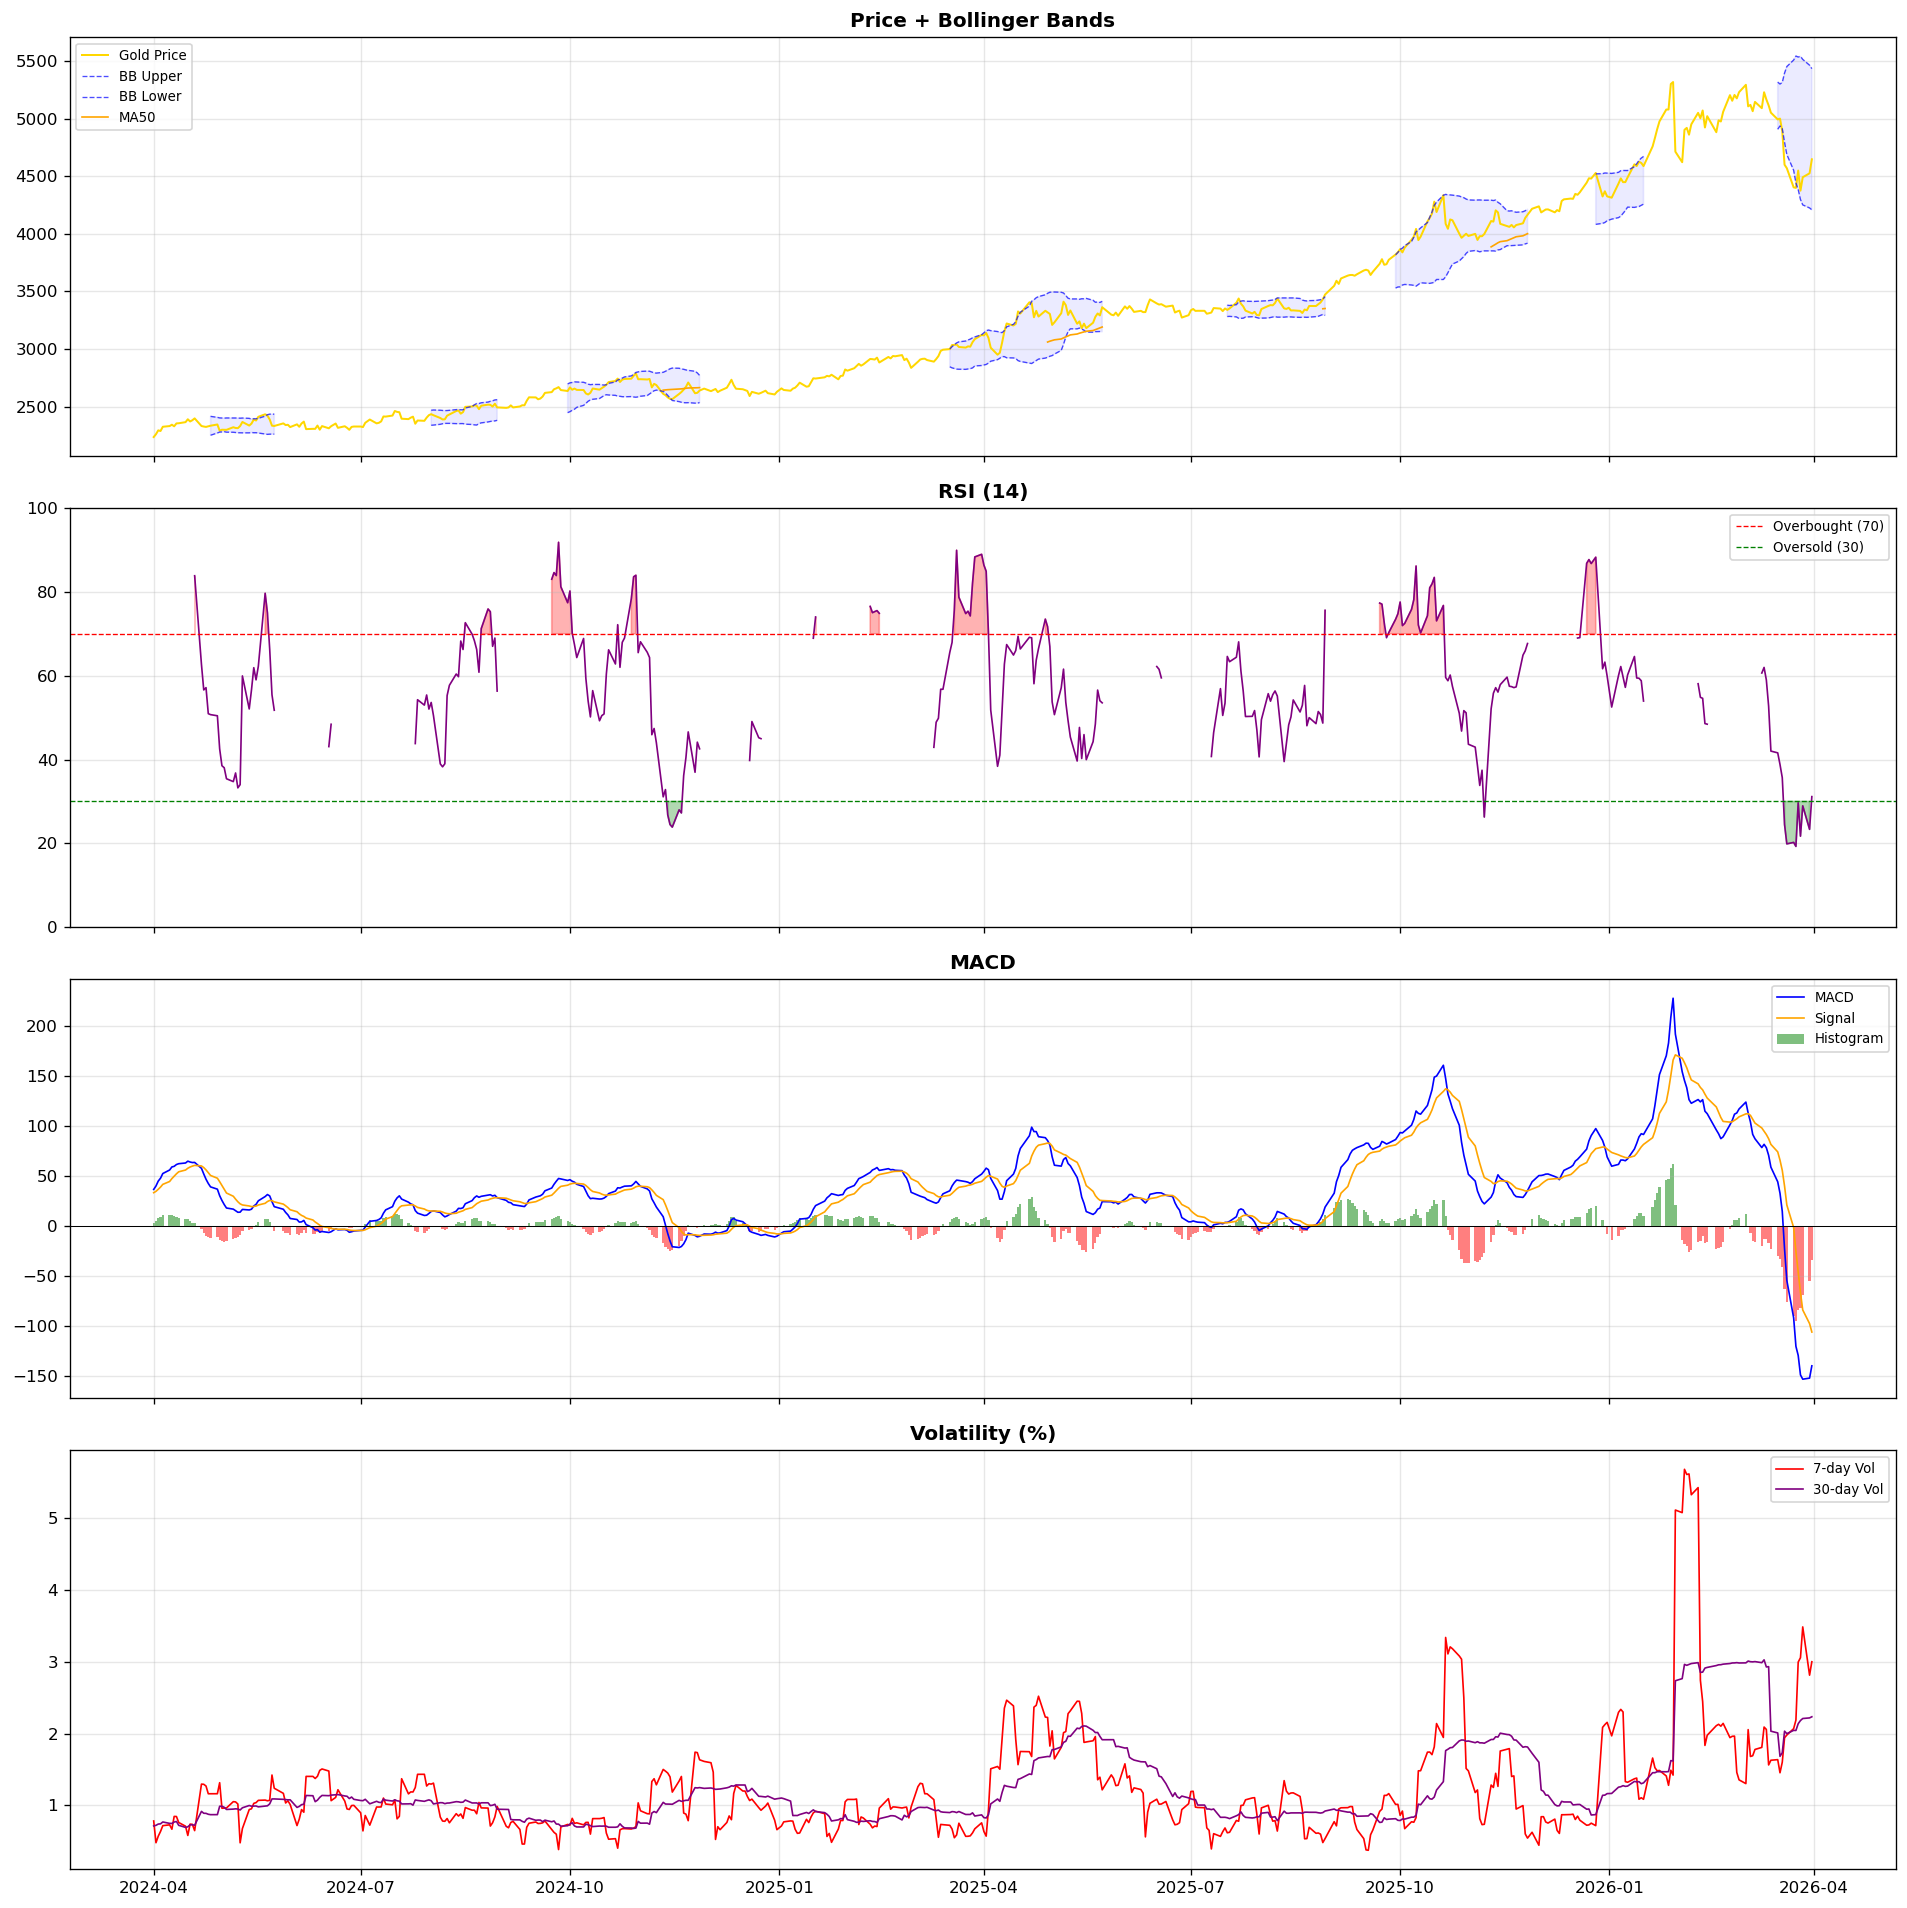

In [14]:
# Show last 2 years for clarity
recent = df.last('730D')

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# --- Price + Bollinger Bands ---
ax = axes[0]
ax.plot(recent.index, recent['Gold_Price'], color='gold', linewidth=1.2, label='Gold Price')
if 'BB_Upper' in recent.columns:
    ax.plot(recent.index, recent['BB_Upper'], 'b--', linewidth=0.8, alpha=0.7, label='BB Upper')
    ax.plot(recent.index, recent['BB_Lower'], 'b--', linewidth=0.8, alpha=0.7, label='BB Lower')
    ax.fill_between(recent.index, recent['BB_Upper'], recent['BB_Lower'], alpha=0.08, color='blue')
if 'MA50' in recent.columns:
    ax.plot(recent.index, recent['MA50'], 'orange', linewidth=1, label='MA50')
ax.set_title('Price + Bollinger Bands', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

# --- RSI ---
ax = axes[1]
if 'RSI_14' in recent.columns:
    ax.plot(recent.index, recent['RSI_14'], color='purple', linewidth=1)
    ax.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
    ax.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
    ax.fill_between(recent.index, recent['RSI_14'], 70,
                    where=recent['RSI_14'] >= 70, alpha=0.3, color='red')
    ax.fill_between(recent.index, recent['RSI_14'], 30,
                    where=recent['RSI_14'] <= 30, alpha=0.3, color='green')
    ax.set_ylim(0, 100)
ax.set_title('RSI (14)', fontweight='bold')
ax.legend(fontsize=8)

# --- MACD ---
ax = axes[2]
if all(c in recent.columns for c in ['MACD', 'MACD_Signal', 'MACD_Hist']):
    ax.plot(recent.index, recent['MACD'],        color='blue',  linewidth=1,   label='MACD')
    ax.plot(recent.index, recent['MACD_Signal'], color='orange', linewidth=1,  label='Signal')
    hist_colors = ['green' if v >= 0 else 'red' for v in recent['MACD_Hist']]
    ax.bar(recent.index, recent['MACD_Hist'], color=hist_colors, alpha=0.5, width=1, label='Histogram')
    ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('MACD', fontweight='bold')
ax.legend(fontsize=8)

# --- Volatility ---
ax = axes[3]
if 'Volatility_7d' in recent.columns:
    ax.plot(recent.index, recent['Volatility_7d']  * 100, color='red',    linewidth=1, label='7-day Vol')
if 'Volatility_30d' in recent.columns:
    ax.plot(recent.index, recent['Volatility_30d'] * 100, color='purple', linewidth=1, label='30-day Vol')
ax.set_title('Volatility (%)', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Seasonality Analysis

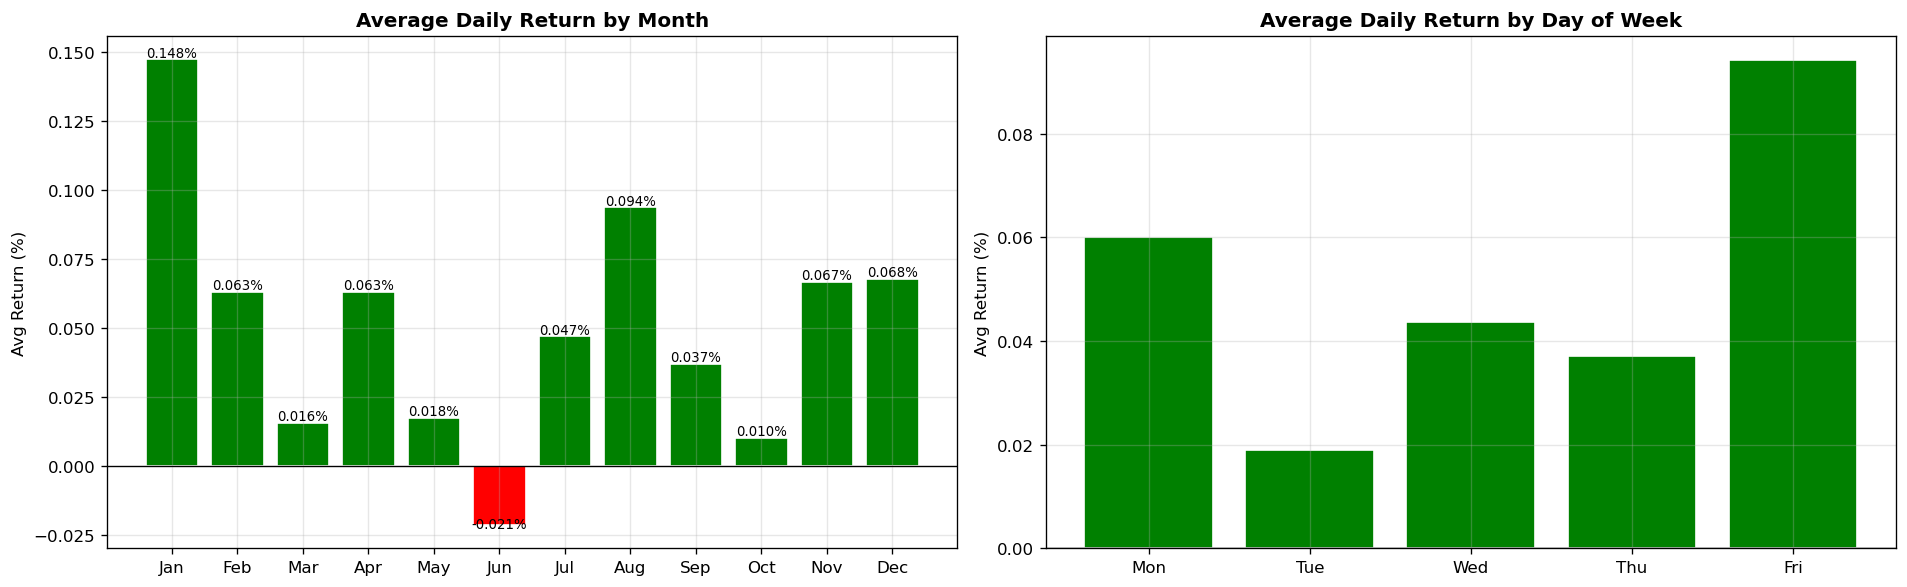

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly average return
df['monthly_ret'] = df['Gold_Price'].pct_change() * 100
monthly_avg = df.groupby(df.index.month)['monthly_ret'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

colors = ['green' if v >= 0 else 'red' for v in monthly_avg]
axes[0].bar(month_names, monthly_avg.values, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Daily Return by Month', fontweight='bold')
axes[0].set_ylabel('Avg Return (%)')
for i, v in enumerate(monthly_avg.values):
    axes[0].text(i, v + 0.001 * np.sign(v), f'{v:.3f}%', ha='center', fontsize=8)

# Day of week
dow_avg = df.groupby(df.index.dayofweek)['monthly_ret'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri']
colors2 = ['green' if v >= 0 else 'red' for v in dow_avg]
axes[1].bar(day_names[:len(dow_avg)], dow_avg.values, color=colors2, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Daily Return by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg Return (%)')

plt.tight_layout()
plt.show()

df.drop(columns='monthly_ret', inplace=True)

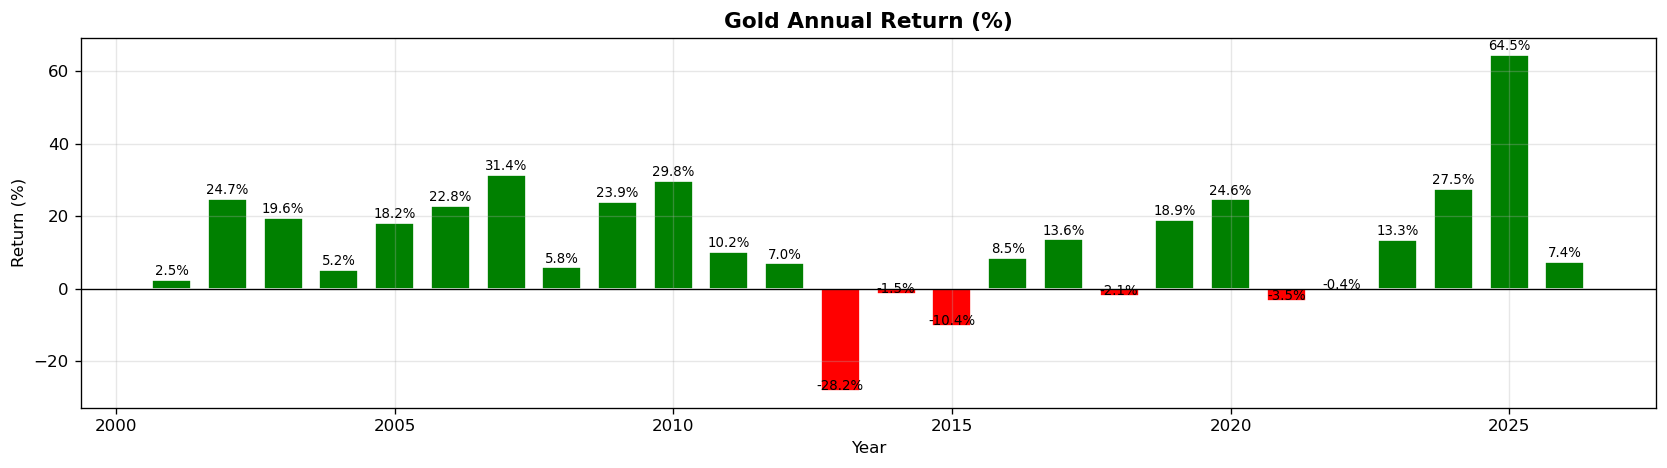

In [16]:
# Yearly performance
yearly = df['Gold_Price'].resample('YE').last().pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if v >= 0 else 'red' for v in yearly.values]
bars = ax.bar(yearly.index.year, yearly.values, color=colors, edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Gold Annual Return (%)', fontweight='bold', fontsize=13)
ax.set_ylabel('Return (%)')
ax.set_xlabel('Year')

for bar, val in zip(bars, yearly.values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5 * np.sign(val),
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Outlier Detection

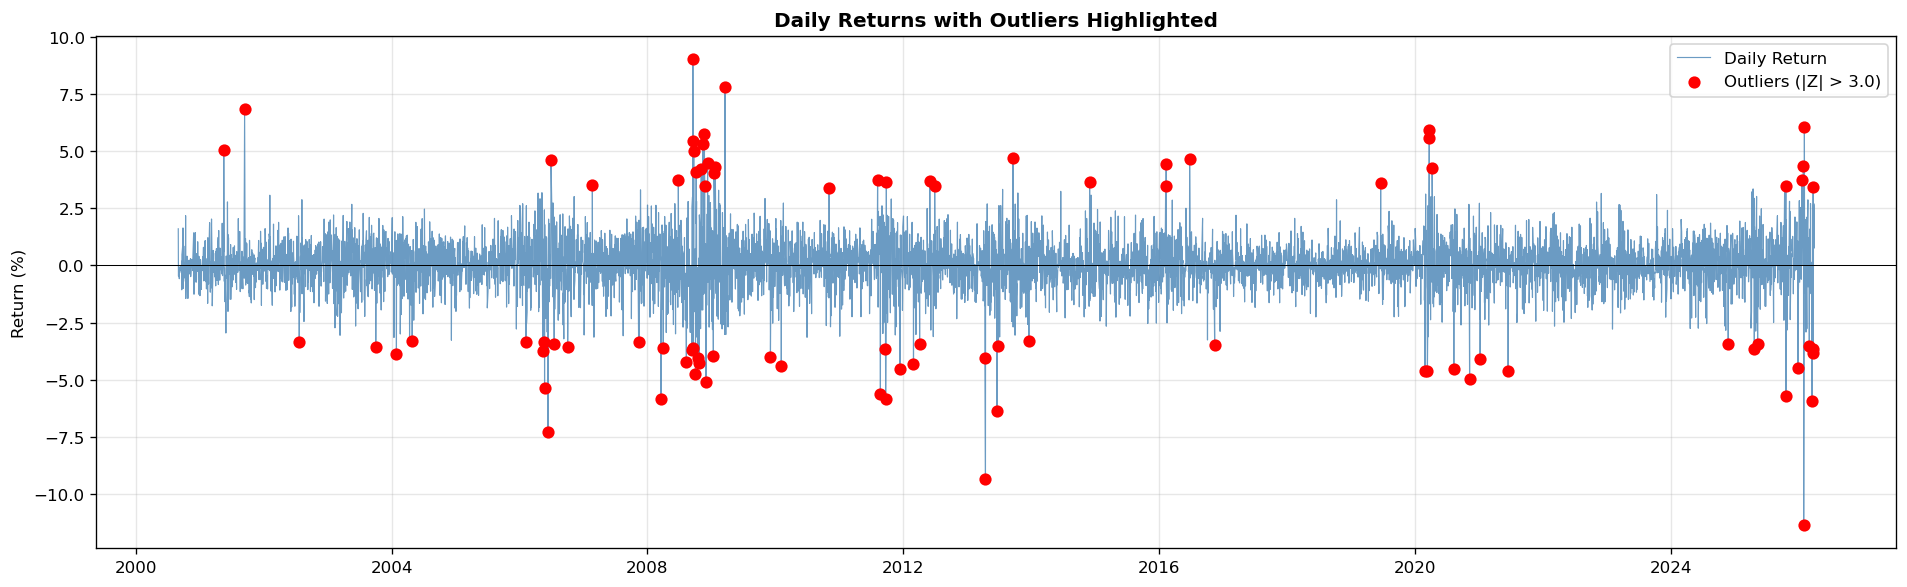

Total outlier days: 88

Biggest drops:
            Return_%
Date                
2026-01-30    -11.37
2013-04-15     -9.35
2006-06-13     -7.30
2013-06-20     -6.38
2026-03-19     -5.91
2011-09-23     -5.85
2008-03-19     -5.83
2025-10-21     -5.74
2011-08-24     -5.61
2006-05-24     -5.35

Biggest gains:
            Return_%
Date                
2001-05-18      5.04
2008-11-14      5.32
2008-09-18      5.45
2020-03-23      5.59
2008-11-21      5.76
2020-03-24      5.95
2026-02-03      6.08
2001-09-14      6.85
2009-03-19      7.83
2008-09-17      9.03


In [17]:
ret = df['Gold_Price'].pct_change() * 100

# Flag outliers using Z-score > 3
z_scores = np.abs(stats.zscore(ret.dropna()))
outlier_threshold = 3.0
outlier_mask = z_scores > outlier_threshold
outlier_dates = ret.dropna().index[outlier_mask]
outlier_values = ret.dropna()[outlier_mask]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, ret, color='steelblue', linewidth=0.7, alpha=0.8, label='Daily Return')
ax.scatter(outlier_dates, outlier_values, color='red', s=40, zorder=5, label=f'Outliers (|Z| > {outlier_threshold})')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Daily Returns with Outliers Highlighted', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total outlier days: {len(outlier_dates)}')
print()
outlier_df = pd.DataFrame({'Return_%': outlier_values.round(2)}).sort_values('Return_%')
print('Biggest drops:')
print(outlier_df.head(10).to_string())
print('\nBiggest gains:')
print(outlier_df.tail(10).to_string())

## 11. Summary & Key Findings

In [19]:
print('=' * 55)
print('  EDA SUMMARY')
print('=' * 55)

print(f'\nDataset:')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {len(df.columns)}')
print(f'  Period  : {df.index[0].date()} to {df.index[-1].date()}')

print(f'\nGold Price:')
print(f'  Min     : ${df["Gold_Price"].min():,.0f}')
print(f'  Max     : ${df["Gold_Price"].max():,.0f}')
print(f'  Mean    : ${df["Gold_Price"].mean():,.0f}')
print(f'  Current : ${df["Gold_Price"].iloc[-1]:,.0f}')

ret = df['Gold_Price'].pct_change() * 100
print(f'\nDaily Returns:')
print(f'  Mean    : {ret.mean():.4f}%')
print(f'  Std Dev : {ret.std():.4f}%')
print(f'  Max Gain: +{ret.max():.2f}%')
print(f'  Max Loss: {ret.min():.2f}%')

print(f'\nMissing Values:')
total_missing = df.isnull().sum().sum()
print(f'  Total missing cells: {total_missing:,}')
cols_with_missing = (df.isnull().sum() > 0).sum()
print(f'  Columns with missing: {cols_with_missing}')

print(f'\nTop correlated features with Gold Price:')
exclude = ['Target_NextDay','Target_Next7d','Target_Direction','DayOfWeek','Month','Quarter','Year']
feature_cols = [c for c in df.columns if c not in exclude]
corr = df[feature_cols].corr()['Gold_Price'].drop('Gold_Price').abs().sort_values(ascending=False)
for feat, val in corr.head(10).items():
    print(f'  {feat:25s}: {val:.3f}')

print('=' * 55)

  EDA SUMMARY

Dataset:
  Rows    : 6,419
  Columns : 69
  Period  : 2000-08-30 to 2026-03-31

Gold Price:
  Min     : $255
  Max     : $5,318
  Mean    : $1,286
  Current : $4,648

Daily Returns:
  Mean    : 0.0504%
  Std Dev : 1.1191%
  Max Gain: +9.03%
  Max Loss: -11.37%

Missing Values:
  Total missing cells: 48,690
  Columns with missing: 46

Top correlated features with Gold Price:
  Lag_1d                   : 1.000
  EMA7                     : 1.000
  Gold_ETF_GLD             : 1.000
  MA7                      : 0.999
  EMA14                    : 0.999
  Lag_3d                   : 0.999
  MA14                     : 0.999
  EMA21                    : 0.999
  MA50                     : 0.998
  Lag_7d                   : 0.998
